# ***Классификация происхождения вопросов для онлайн-игры (проект ВК)*** 

## Описание проекта 
Разработка модели, способной отличать вопросы, подготовленные профессиональными редакторами, от вопросов, предложенных пользователями игры. Задача решается с помощью методов классификации текстов.

## Бизнес задача 
Автоматизация модерации контента, повышение качества игрового опыта за счёт выделения редакторских вопросов

## Ключевые результаты
- **Лучшая модель:** XGBoost с подбором гиперпараметров
- **Recall (класс 1 - редакторы):** 50% (найдена половина редакторских вопросов)
- **Recall (класс 0 - пользователи):** 71%
- **Accuracy:** 69%

Результат достигнут после подбора порога классификации (0,452)
По условиям задачи требовалось загрузить вероятности, поэтому в финальный файл `test_predictions.csv` сохранены вероятности класса 1 из модели XGBoost без применения порога

## Ключевые выводы
- **Данные сильно несбалансированы:** 90% пользовательских вопросов против 10% редакторских  
- **Лексика классов сильно пересекается,** что усложняет задачу  
- **XGBoost показал лучший результат** среди всех моделей  
- **Подбор порога** позволил повысить recall до 50% за счёт точности  
- **Ансамбли не дали значимого улучшения**

## Структура проекта
- `notebooks/classification_questions.ipynb` - полный анализ
- `models/best_xgboost.pkl` - сохранённая модель
- `results/test_predictions.csv'` - предсказания для тестовой выборки

# 1. Загрузка и предобработка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('../data/data.csv', delimiter=';', index_col=0)
data

,Question
ID,
1,Как зовут лодочника на реке Стикс в древнегреч...
2,Как в химии обозначается свинец?
3,Какой химический элемент преобладает в составе...
4,Кто из перечисленных был пажом во времена Екат...
5,Когда началась 2 мировая война?
...,...
41083,В каком году распался СССР
41084,Сколько калорий в 100 гр арбуза?
41085,"Сколько хвостов у лиса, который является демон..."


In [4]:
train = pd.read_csv('../data/train.csv', delimiter=';', index_col=0)
test = pd.read_csv('../data/test.csv', delimiter=';', index_col=0)

In [5]:
df = pd.concat([data, train], axis=1)
df = df.dropna()
df['Answer'] = df['Answer'].astype(int)
df

,Question,Answer
ID,,
1,Как зовут лодочника на реке Стикс в древнегреч...,0
2,Как в химии обозначается свинец?,1
3,Какой химический элемент преобладает в составе...,0
4,Кто из перечисленных был пажом во времена Екат...,0
5,Когда началась 2 мировая война?,0
...,...,...
29996,"Как называется игра, местом действия которой я...",0
29997,Как в опере называют ведущую певицу?,0
29998,На какой планете сутки длиннее года?,0


In [6]:
test_df = pd.concat([data.loc[test.index], test], axis=1)
test_df

,Question
ID,
30001,"Что в литературе обозначает слово ""эпитет""?"
30002,Когда отмечается ДЕНЬ ШОКОЛАДА
30003,Кто из этих бодибилдеров играл Халка
30004,"Последняя на данный момент страна, официально ..."
30005,Как зовут лютоволка Арьи Старк из сериала «Иг...
...,...
41083,В каком году распался СССР
41084,Сколько калорий в 100 гр арбуза?
41085,"Сколько хвостов у лиса, который является демон..."


# 2. EDA (Разведочный анализ данных)
## 2.1. Распределение классов 

In [7]:
df.isna().sum()

Question    0
Answer      0
dtype: int64

<Axes: xlabel='Answer', ylabel='count'>

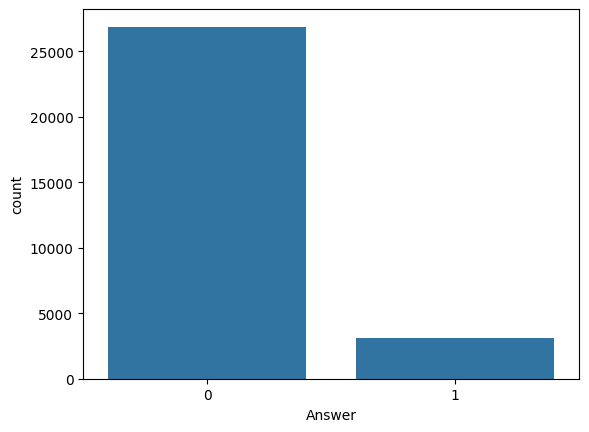

In [8]:
sns.countplot(data=df, x='Answer')

---
Вывод: сильный дисбаланс классов 

---

## 2.2. Анализ текста

In [9]:
import nltk

from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords

In [10]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Лера\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
russian_stop = stopwords.words('russian')

In [12]:
for label in [0, 1]:
    cv = CountVectorizer(stop_words=russian_stop)
    matrix = cv.fit_transform(df[df['Answer'] == label]['Question'])
    freqs = zip(cv.get_feature_names_out(), matrix.sum(axis=0).tolist()[0])
    top_words = [word for word, count in sorted(freqs, key=lambda x: -x[1])[:10]]
    print(f'Топ 10 слов для класса {label}: {top_words}')

Топ 10 слов для класса 0: ['сколько', 'каком', 'году', 'является', 'этих', 'называется', 'какого', 'какое', 'россии', 'первый']
Топ 10 слов для класса 1: ['каком', 'году', 'сколько', 'называется', 'этих', 'является', 'какое', 'какого', 'город', 'звали']


# 3. Подготовка данных к моделированию 
## 3.1. Разделение на train / test

In [13]:
X = df['Question']
y = df['Answer']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 3.2. Векторизация текста (TF-IDF)

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [17]:
tfidf = TfidfVectorizer(stop_words=russian_stop, max_features=10000, ngram_range=(1, 3))

# 4. Построение и оценка моделей 
## 4.1. Сравнение базовых моделей (кросс-валидация)

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC

from sklearn.model_selection import cross_val_score

In [19]:
pipeline_logreg = Pipeline([
    ('tfidf', tfidf), 
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipeline_xgboost = Pipeline([
    ('tfidf', tfidf), 
    ('model', XGBClassifier(scale_pos_weight=8, random_state=42))
])

pipeline_linearSVC = Pipeline([
    ('tfidf', tfidf), 
    ('model', LinearSVC(class_weight='balanced'))
])

In [20]:
pipelines = {
    'Logistic Regression': pipeline_logreg,
    'XGBoost': pipeline_xgboost,
    'Linear SVC': pipeline_linearSVC
}

In [21]:
for name, model in pipelines.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    print(f'{name}: F1-macro = {scores.mean():.2f}')

Logistic Regression: F1-macro = 0.51
XGBoost: F1-macro = 0.54
Linear SVC: F1-macro = 0.51


## 4.2. XGBoost с подбором гиперпараметров

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

In [23]:
param_distributions = {
    'model__n_estimators': [200, 400, 600], 
    'model__learning_rate': np.linspace(0.01, 0.2, 10), 
    'model__max_depth': [3, 5, 8], 
    'model__reg_alpha': np.linspace(0, 5, 10), 
    'model__reg_lambda': np.linspace(0, 5, 10)
}

In [24]:
random_search = RandomizedSearchCV(
    estimator=pipeline_xgboost, 
    param_distributions=param_distributions, 
    n_iter=20, 
    scoring='f1_macro', 
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

In [25]:
random_search.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__learning_rate': array([0.01 ..., 0.2 ]), 'model__max_depth': [3, 5, ...], 'model__n_estimators': [200, 400, ...], 'model__reg_alpha': array([0. ..., 5. ]), ...}"
,n_iter,20
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [26]:
random_search.best_params_

{'model__reg_lambda': 5.0,
 'model__reg_alpha': 3.3333333333333335,
 'model__n_estimators': 400,
 'model__max_depth': 8,
 'model__learning_rate': 0.01}

In [27]:
preds_xgboost = random_search.predict(X_test)

In [28]:
print(classification_report(y_test, preds_xgboost))

              precision    recall  f1-score   support

           0       0.91      0.79      0.85      8059
           1       0.17      0.36      0.23       941

    accuracy                           0.75      9000
   macro avg       0.54      0.58      0.54      9000
weighted avg       0.84      0.75      0.78      9000



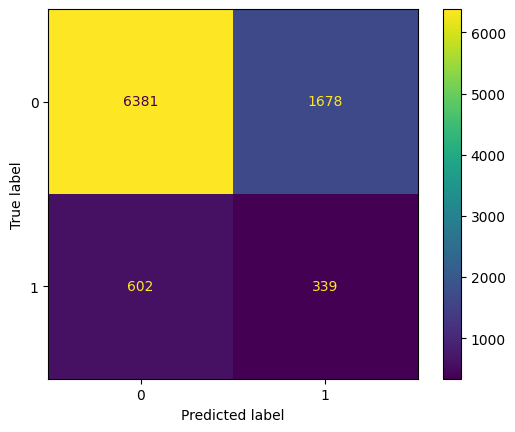

In [29]:
ConfusionMatrixDisplay.from_predictions(y_test, preds_xgboost)

## 4.3. Оптимизация порога классификации

In [30]:
from sklearn.metrics import RocCurveDisplay, roc_curve

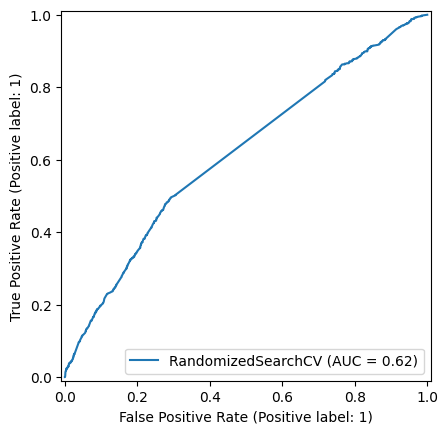

In [31]:
RocCurveDisplay.from_estimator(random_search, X_test, y_test)

In [32]:
probs = random_search.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probs)
best_idx = np.argmax(tpr-fpr)
best_threshold = thresholds[best_idx]

print(f'Лучший порог: {best_threshold}')
print(f'Recall (TPR) при нем: {tpr[best_idx]}')
print(f'FPR при нем: {fpr[best_idx]}')

Лучший порог: 0.45192644000053406
Recall (TPR) при нем: 0.4962805526036132
FPR при нем: 0.29308847251520037


In [33]:
best_preds_xgboost = (probs > best_threshold).astype(int)

In [34]:
print(classification_report(y_test, best_preds_xgboost))

              precision    recall  f1-score   support

           0       0.92      0.71      0.80      8059
           1       0.17      0.50      0.25       941

    accuracy                           0.69      9000
   macro avg       0.54      0.60      0.52      9000
weighted avg       0.84      0.69      0.74      9000



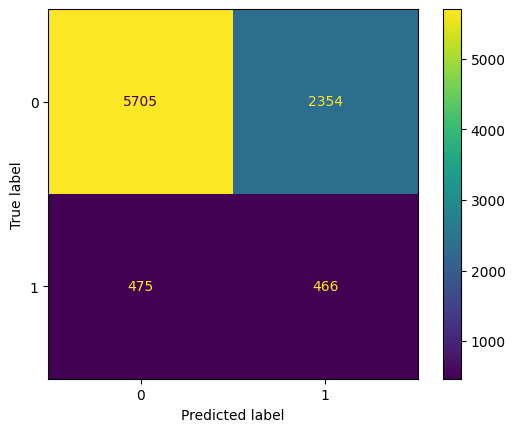

In [35]:
ConfusionMatrixDisplay.from_predictions(y_test, best_preds_xgboost)

## 4.4. Ансамбль моделей (VotingClassifier)
Объединение Logistic Regression и XGBoost (voting='soft', weights=[1,2])

In [36]:
from sklearn.ensemble import VotingClassifier

In [37]:
ensemble = VotingClassifier(
    estimators=[
        ('logreg', pipeline_logreg), 
        ('xgboost', random_search.best_estimator_)
    ], 
    voting='soft', 
    weights=[1, 2]
)

In [38]:
ensemble.fit(X_train, y_train)

,estimators,"[('logreg', ...), ('xgboost', ...)]"
,voting,'soft'
,weights,"[1, 2]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True


In [39]:
preds_ensemble = ensemble.predict(X_test)

In [40]:
print(classification_report(y_test, preds_ensemble))

              precision    recall  f1-score   support

           0       0.91      0.77      0.84      8059
           1       0.16      0.38      0.23       941

    accuracy                           0.73      9000
   macro avg       0.54      0.57      0.53      9000
weighted avg       0.84      0.73      0.77      9000



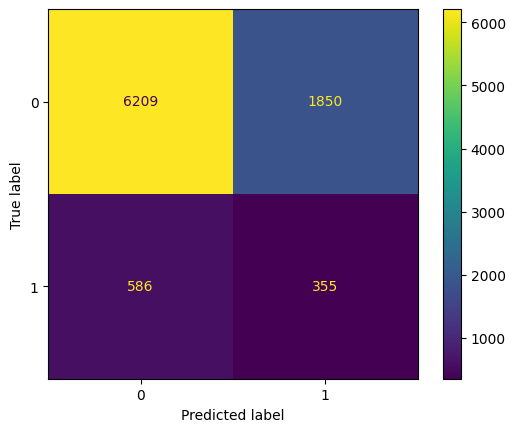

In [41]:
ConfusionMatrixDisplay.from_predictions(y_test, preds_ensemble)

# 5. Итоговый выбор модели 

Лучшей моделью признан XGBoost с подобранными гиперпараметрами. 
На тестовой выборке после подбора порога (0.452) удалось достичь recall 50% для класса редакторских вопросов

**Метрики на тесте (после подбора порога):**
- Recall (класс 1): 50%
- Precision (класс 1): 17%
- F1 (класс 1): 0.25
- Accuracy: 69%

**Финальный файл для сдачи:**
По условиям задачи требовалось загрузить **вероятности**, а не бинарные метки.  
Поэтому порог не применялся - сохранены вероятности класса 1 из модели XGBoost.

In [42]:
import joblib

In [43]:
best_model = random_search.best_estimator_

In [44]:
joblib.dump(best_model, '../models/best_xgboost.pkl')

['../models/best_xgboost.pkl']

In [50]:
test_texts = test_df['Question']
probs = best_model.predict_proba(test_texts)[:, 1]

In [52]:
answers = pd.DataFrame({
    'ID': test_df.index,
    'pred': probs
})
answers.to_csv('../results/test_predictions.csv', index=False, sep=';')